# Functions

In [1]:
#import relevant libraries
#Load modules
import os
import pandas as pd
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns

from struct import *
import osar
import scipy as sp
import re
import dabest

import warnings
from datetime import datetime
import scikits.bootstrap as skb
from osar.plot_helpers.plot_helpers import r2_and_slope

date = datetime.today().strftime('%Y%m%d')
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

import warnings
warnings.filterwarnings("ignore")


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 32.26it/s]

Numba compilation complete!


In [ ]:
def chartplottingdabest(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names] = filter1[parameter]
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst)    
    tab = pd.concat([test.mean_diff.results['test'], test.mean_diff.results['difference']], axis = 1)
    
    arrangedsorting = tab.sort_values(by=['difference'], ascending = True).reset_index(drop=True)

    newlist = []
    for n in arrangedsorting['test']:
        newlist.append((n +" Cntrl", n))

    return dfr1, arrangedsorting['test'], newlist

def singleplottingdabest(dfi, names, parameter):
    import dabest_nbdev
    dfrr = pd.DataFrame()
    filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
    filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

    dfrr[names + " Cntrl" ] = filter2[parameter]
    dfrr[names] = filter1[parameter]
    #dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfrr.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    test = dabest.load(dfrr, idx=titlelst, ci=90)    
    
    return test

# Code

In [2]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = labcomp

root = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_test\\"

In [ ]:
responder = "ACR"
filepath = root + responder + " 20250114_compilation_full.csv"
df2= pd.read_csv(filepath)

basegenotype = df2['driver'].unique()

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Full')].copy()
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

In [10]:
dfpi, sortedlist, dabestlist = chartplottingdabest(dfi, basegenotype, 'pi_smoothed_Pattern 01')
dfspeed, notsortedlist, notdabestlist = chartplottingdabest(dfi, basegenotype, 'log2_speed_ratio_Pattern 01')

In [14]:
piplot = dabest.load(dfpi, idx=dabestlist)
spplot = dabest.load(dfspeed, idx=dabestlist)

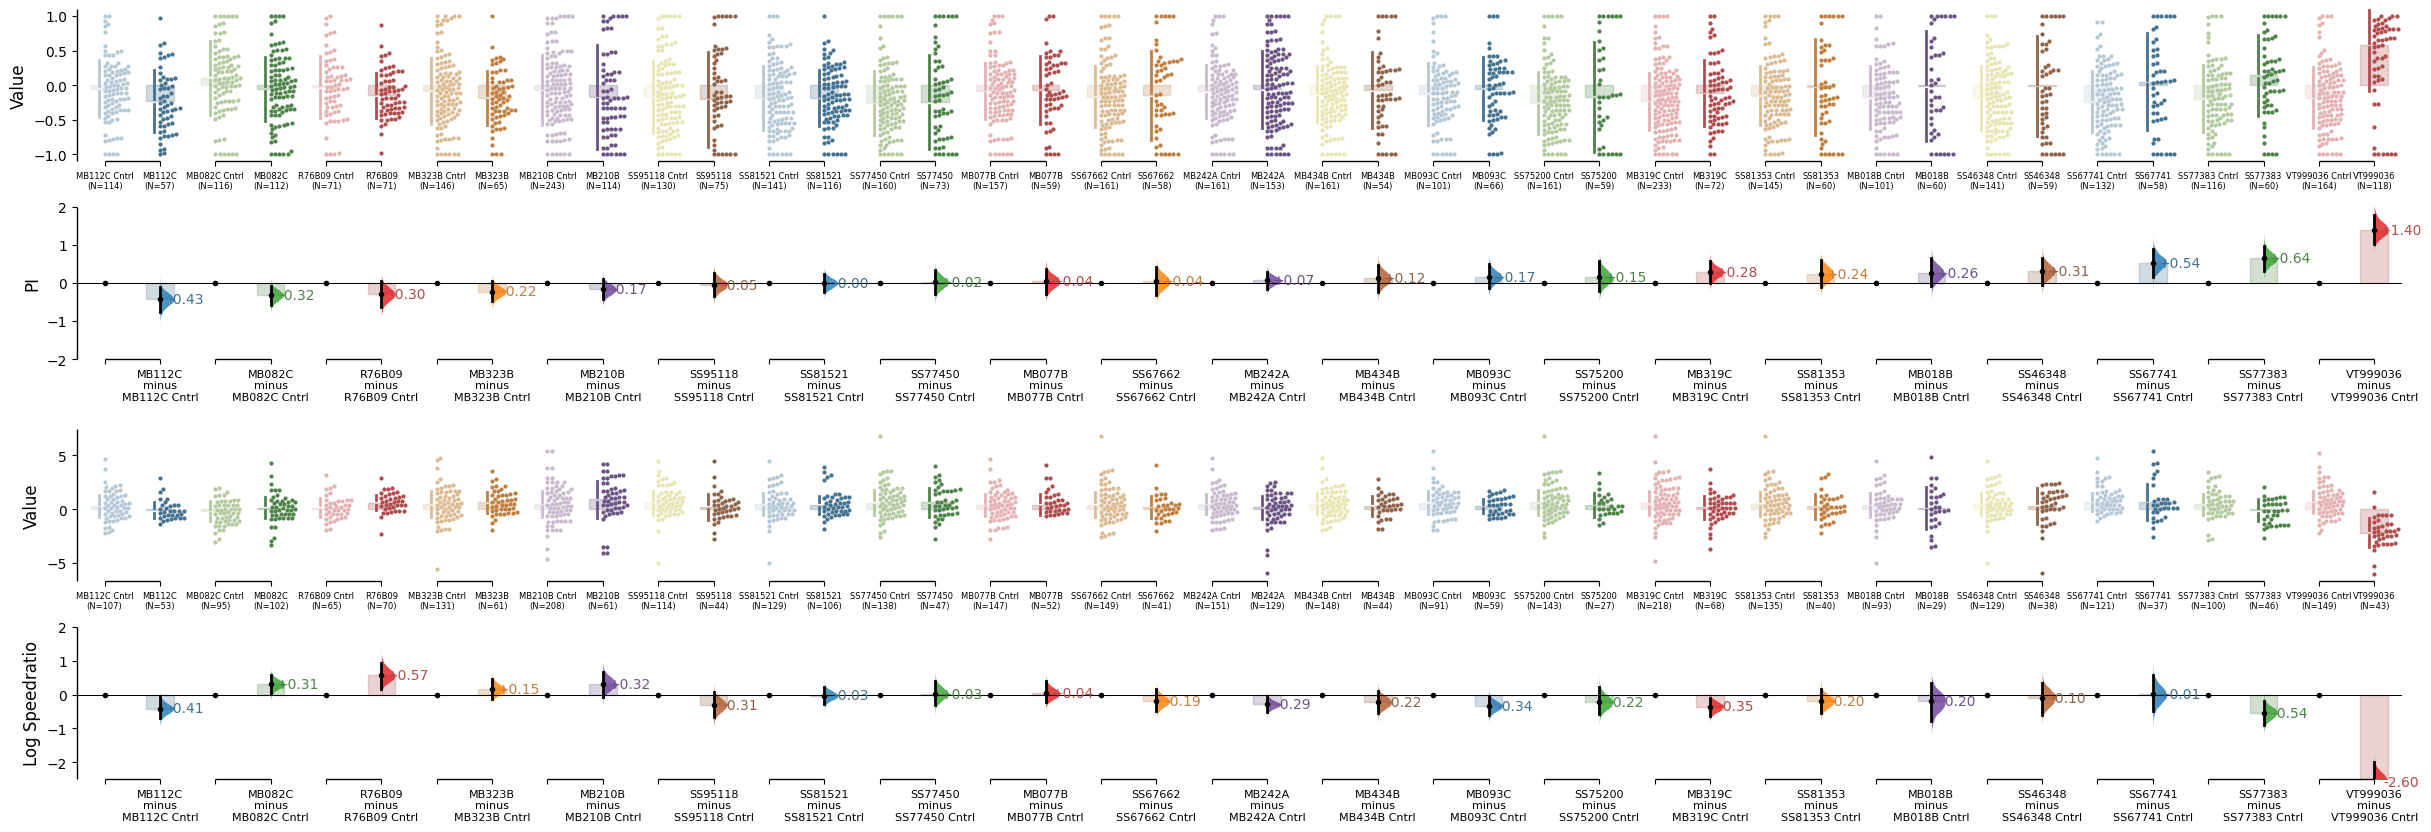

In [17]:
f, axx = plt.subplots(nrows=2, ncols=1,
                    figsize=(30
                             ,10) # ensure proper width-wise spacing.
                   )
piplot.hedges_g.plot(fontsize_rawxlabel=6, fontsize_contrastxlabel=8, float_contrast=False, raw_marker_size=1, contrast_marker_size=3, 
                      custom_palette="Paired", contrast_label="PI", contrast_ylim=(-2,2), ax=axx.flat[0]);

spplot.hedges_g.plot(fontsize_rawxlabel=6, fontsize_contrastxlabel=8, float_contrast=False, raw_marker_size=1, contrast_marker_size=3, 
                      custom_palette="Paired", contrast_label="Log Speedratio", contrast_ylim=(-2.5,2), ax=axx.flat[1]);

#sns.set(font_scale=0.5,  style='ticks')

In [ ]:
# filename = folderpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2024images\\" + date + 'compilation_' + genot + '_totalplots_Full_light'
# f.savefig(filename + '.svg', bbox_inches="tight", dpi=600)

## Addition of singular plots

In [ ]:
filepath = root + responder + " 20250114_compilation_full.csv"
df2= pd.read_csv(filepath)

basegenotype = df2['driver'].unique()

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Full')].copy()
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

basegenotype

array(['MB077B', 'MB082C', 'MB093C', 'MB112C', 'MB210C', 'MB242A',
       'MB310C', 'MB323B', 'MB434B', 'R76B09', 'SS46348', 'SS67662',
       'SS67741', 'SS75200', 'SS77450', 'SS81353', 'SS81521', 'SS95118',
       'VT999036'], dtype=object)

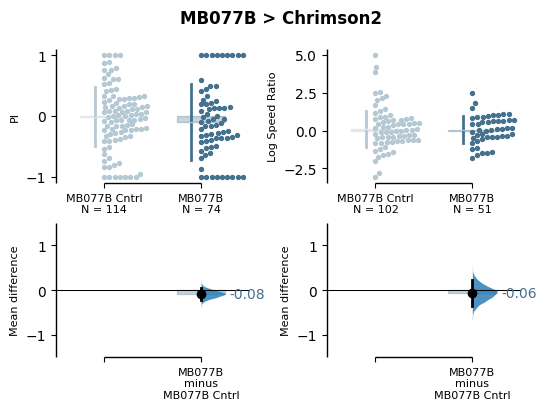

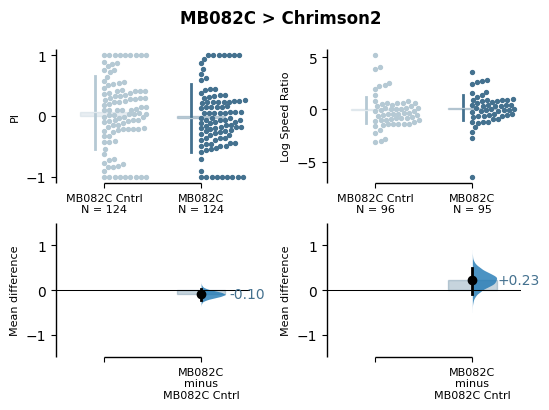

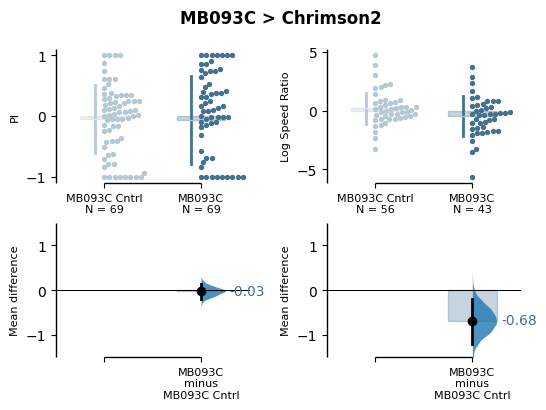

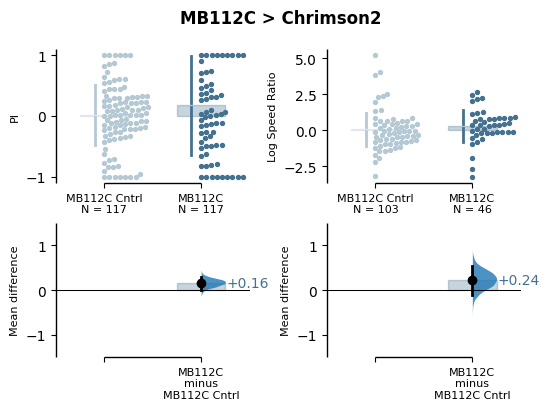

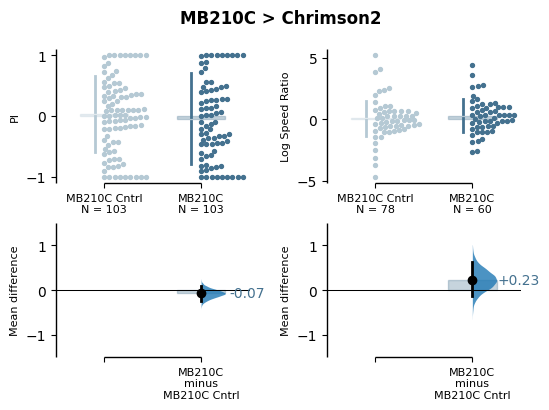

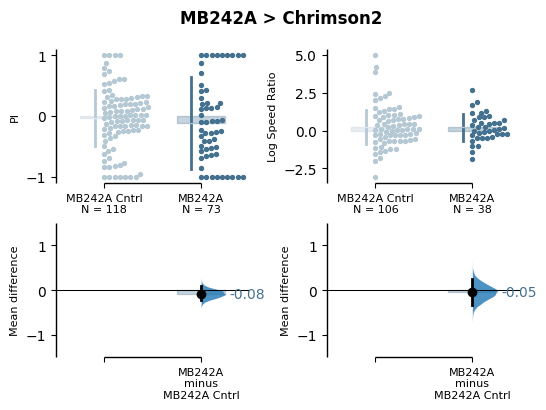

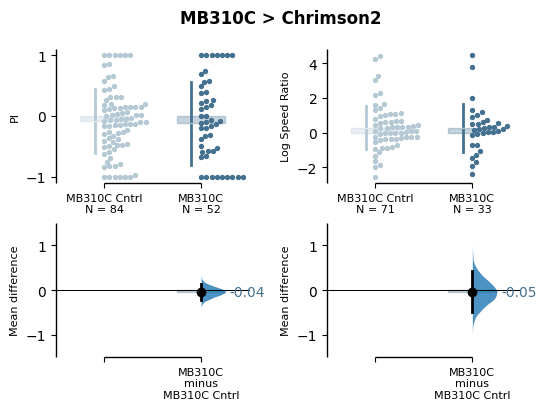

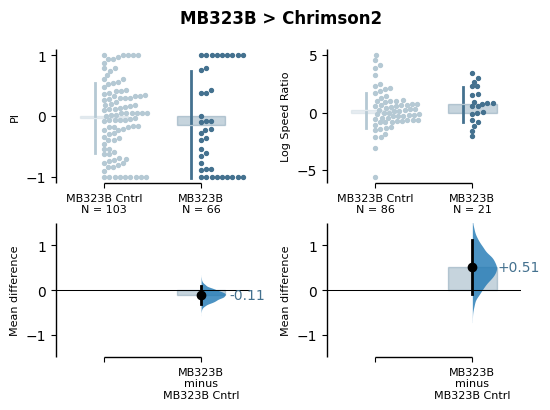

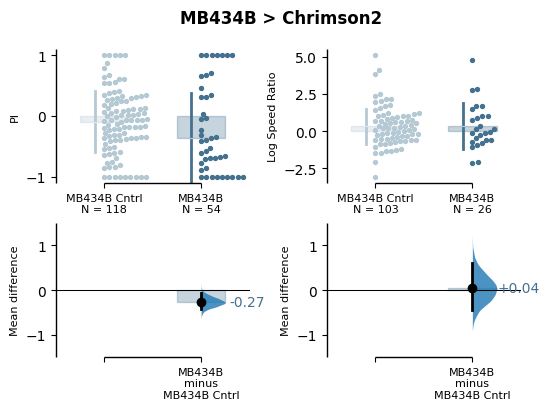

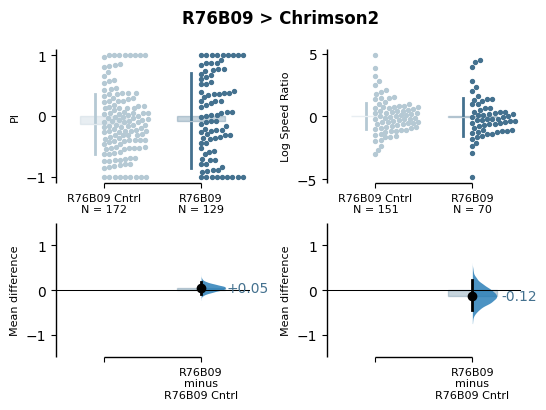

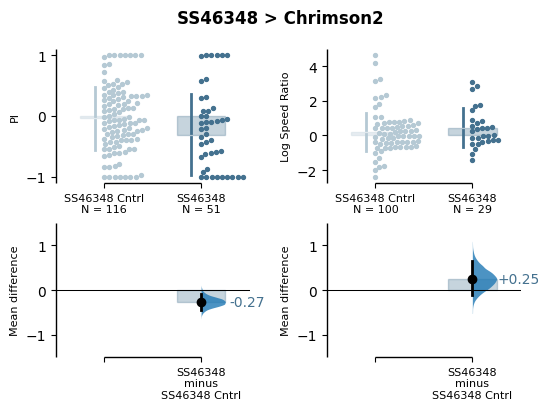

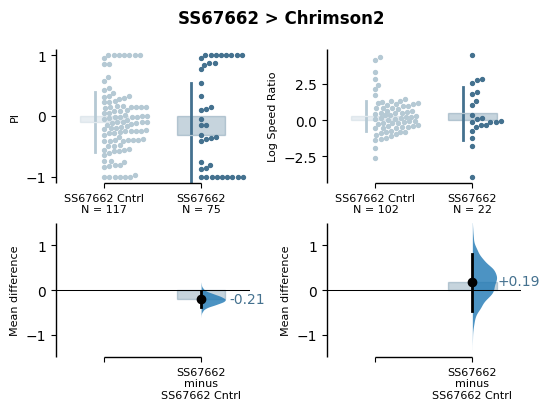

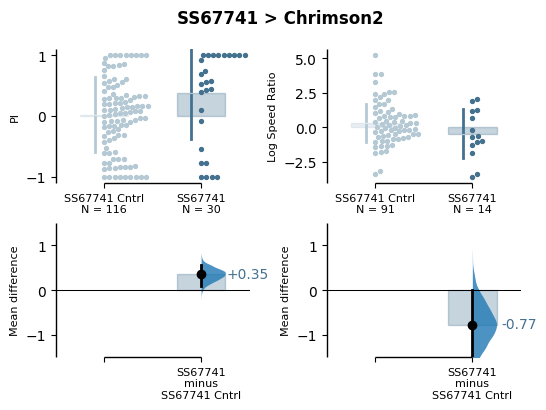

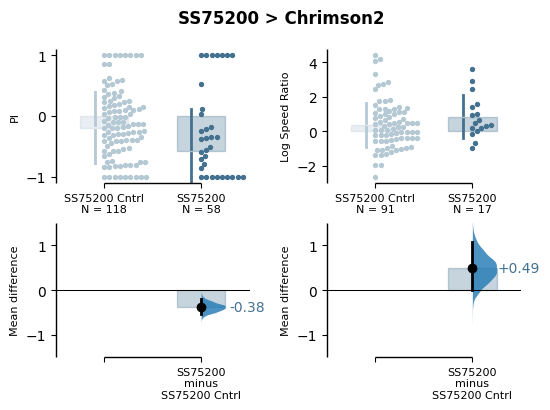

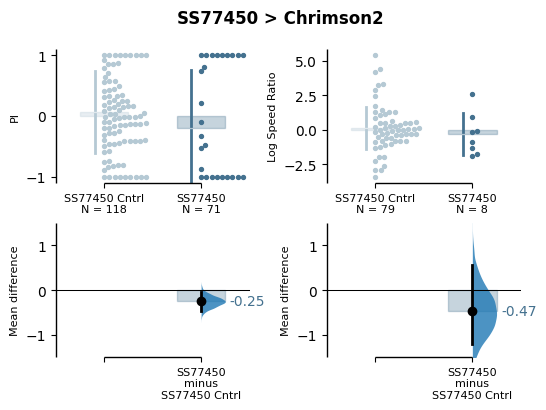

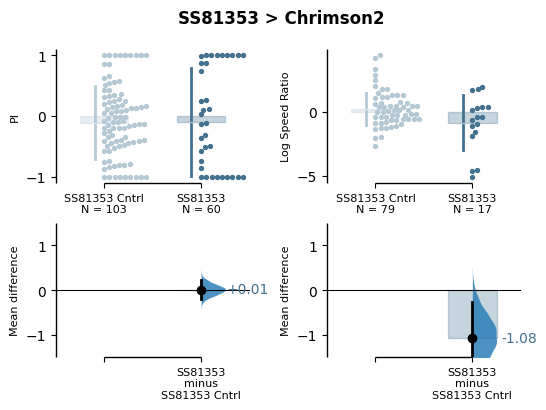

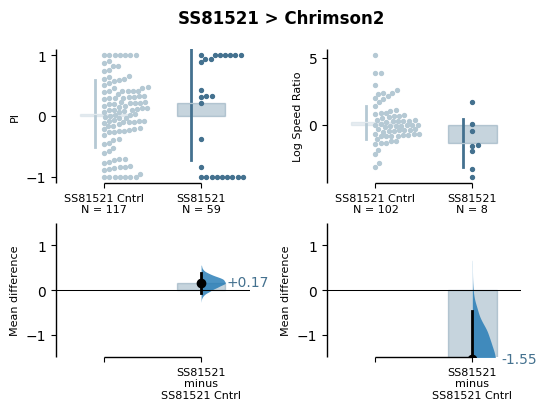

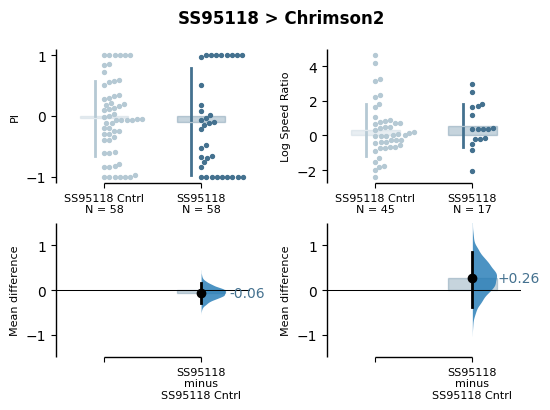

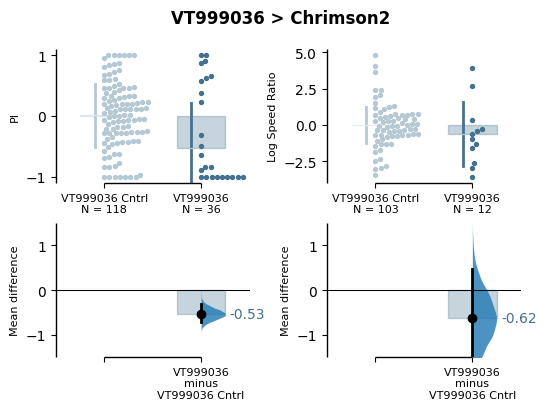

In [ ]:
for n in basegenotype:
   
   figure2, axx = plt.subplots(nrows=1, ncols=2,
                    figsize=(6
                             ,4), gridspec_kw={'wspace': 0.4}
                                # ensure proper width-wise spacing.
                   )

   singleplottingdabest(dfi, n, "pi_smoothed_Pattern 01").mean_diff.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, 
        fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, es_marker_size=6, 
                         custom_palette="Paired", swarm_label="PI", contrast_ylim=(-1.5,1.5), ax=axx.flat[0]);

   singleplottingdabest(dfi, n, "log2_speed_ratio_Pattern 01").mean_diff.plot(float_contrast=False, fontsize_rawylabel=8,fontsize_rawxlabel=8, 
        fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, es_marker_size=6, 
                        custom_palette="Paired", swarm_label="Log Speed Ratio", contrast_ylim=(-1.5,1.5), ax=axx.flat[1]);

   pivalue = round(singleplottingdabest(dfi, n, "pi_smoothed_Pattern 01").mean_diff.results['difference'],2).values[0]
   srvalue = round(singleplottingdabest(dfi, n, "log2_speed_ratio_Pattern 01").mean_diff.results['difference'],2).values[0]

   figure2.tight_layout()
   figure2.suptitle( n + " > " + responder, fontweight='bold', size = 12, y=0.98)
   # axx[0].text(1.75, 1.2,  r"$\bf{PI:}$" + str(pivalue), fontsize = 10, transform=axx[0].transAxes)
   # axx[1].text(0.8, 1.2,  r"$\bf{SR:}$" + str(srvalue) , fontsize = 10, transform=axx[1].transAxes)
   
   #filesaving
   # filename = folderpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2024images\\" +  n + " x " + genot + '_OSAR_Full_light'
   # figure2.savefig(filename + '.svg', bbox_inches="tight", dpi=600)

